In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
import warnings
warnings.filterwarnings('ignore')

In [10]:
def residual_block(x, filters, kernel_size=3, stride=1, conv_shortcut=True, name=None):
    """A residual block."""
    if conv_shortcut:
        shortcut = layers.Conv2D(4 * filters, 1, strides=stride, name=name + '_0_conv')(x)
        shortcut = layers.BatchNormalization(axis=3, epsilon=1.001e-5, name=name + '_0_bn')(shortcut)
    else:
        shortcut = x

    x = layers.Conv2D(filters, 1, strides=stride, name=name + '_1_conv')(x)
    x = layers.BatchNormalization(axis=3, epsilon=1.001e-5, name=name + '_1_bn')(x)
    x = layers.Activation('relu', name=name + '_1_relu')(x)

    x = layers.Conv2D(filters, kernel_size, padding='same', name=name + '_2_conv')(x)
    x = layers.BatchNormalization(axis=3, epsilon=1.001e-5, name=name + '_2_bn')(x)
    x = layers.Activation('relu', name=name + '_2_relu')(x)

    x = layers.Conv2D(4 * filters, 1, name=name + '_3_conv')(x)
    x = layers.BatchNormalization(axis=3, epsilon=1.001e-5, name=name + '_3_bn')(x)

    x = layers.Add(name=name + '_add')([shortcut, x])
    x = layers.Activation('relu', name=name + '_out')(x)
    return x

In [11]:
def stack(x, filters, blocks, stride1=2, name=None):
    """A set of stacked residual blocks."""
    x = residual_block(x, filters, stride=stride1, name=name + '_block1')
    for i in range(2, blocks + 1):
        x = residual_block(x, filters, conv_shortcut=False, name=name + '_block' + str(i))
    return x

In [12]:
def build_resnet_detection_model(input_shape=(128, 128, 1), num_classes=3):
    """Build a ResNet-based model for oil spill detection."""
    inputs = layers.Input(shape=input_shape)
    
    # Convert grayscale to RGB if needed for pretrained weights
    if input_shape[-1] == 1:
        x = layers.Conv2D(3, (1, 1), padding='same', name='rgb_conv')(inputs)
    else:
        x = inputs
    
    # Stem
    x = layers.ZeroPadding2D(padding=((3, 3), (3, 3)), name='conv1_pad')(x)
    x = layers.Conv2D(64, 7, strides=2, use_bias=False, name='conv1_conv')(x)
    x = layers.BatchNormalization(axis=3, epsilon=1.001e-5, name='conv1_bn')(x)
    x = layers.Activation('relu', name='conv1_relu')(x)
    
    x = layers.ZeroPadding2D(padding=((1, 1), (1, 1)), name='pool1_pad')(x)
    x = layers.MaxPooling2D(3, strides=2, name='pool1_pool')(x)
    
    # ResNet blocks
    x = stack(x, 64, 3, stride1=1, name='conv2')
    x = stack(x, 128, 4, name='conv3')
    x = stack(x, 256, 6, name='conv4')
    x = stack(x, 512, 3, name='conv5')
    
    # Classification head
    x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
    x = layers.Dense(512, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.4, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    
    model = models.Model(inputs, outputs, name='resnet50_oil_detection')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [13]:
def build_resnet_unet(input_shape=(128, 128, 1)):
    """Build a U-Net with ResNet backbone for segmentation."""
    inputs = layers.Input(shape=input_shape)
    
    # Encoder (Simple ResNet-inspired backbone)
    # Block 1
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    # Block 2 with skip connection
    shortcut2 = layers.Conv2D(128, 1, padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    c2 = layers.Add()([c2, shortcut2])
    c2 = layers.Activation('relu')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    
    # Block 3 with skip connection
    shortcut3 = layers.Conv2D(256, 1, padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    c3 = layers.Add()([c3, shortcut3])
    c3 = layers.Activation('relu')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)
    
    # Block 4 with skip connection
    shortcut4 = layers.Conv2D(512, 1, padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(c4)
    c4 = layers.Add()([c4, shortcut4])
    c4 = layers.Activation('relu')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)
    
    # Bottleneck with skip connection
    shortcut5 = layers.Conv2D(1024, 1, padding='same')(p4)
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(c5)
    c5 = layers.Add()([c5, shortcut5])
    c5 = layers.Activation('relu')(c5)
    
    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(c6)
    
    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(c7)
    
    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(c8)
    
    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(c9)
    
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)
    
    model = models.Model(inputs=[inputs], outputs=[outputs], name="ResNet_UNet_OilSpill_Segmentation")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

In [14]:
detection_model = build_resnet_detection_model()
detection_model.summary()

Model: "resnet50_oil_detection"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_conv (Conv2D)   │ (None, 128, 128,  │          6 │ input_layer_2[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ rgb_conv[0][0]    │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c

 Total params: 24,638,281 (93.99 MB)

 Trainable params: 24,585,161 (93.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [15]:
segmentation_model = build_resnet_unet()
segmentation_model.summary()

Model: "ResNet_UNet_OilSpill_Segmentation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_3[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      8,320 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ conv2d_4[0][0],   │
│                     │ 128)              │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     33,024 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ conv2d_7[0][0],   │
│                     │ 256)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_3[

 Total params: 31,728,833 (121.04 MB)

 Trainable params: 31,728,833 (121.04 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [17]:
dataset_path = "/Volumes/Windows8_OS/Dataset/Dataset-OG-PNG/Images/"

In [18]:
train_dir = dataset_path

In [19]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

In [20]:
train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    color_mode='grayscale',
    batch_size=16,
    class_mode='categorical',  # 3-class classification
    subset='training'
)

Found 360 images belonging to 3 classes.


In [21]:
val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    color_mode='grayscale',
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 90 images belonging to 3 classes.


In [22]:
model = build_resnet_detection_model()

In [23]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    verbose=1
)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 168s 6s/step - accuracy: 0.3766 - loss: 9.8719 - val_accuracy: 0.3333 - val_loss: 225.6719
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 126s 5s/step - accuracy: 0.3814 - loss: 7.5670 - val_accuracy: 0.3333 - val_loss: 671.9211
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 126s 5s/step - accuracy: 0.4241 - loss: 6.5491 - val_accuracy: 0.3778 - val_loss: 4.2941
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 124s 5s/step - accuracy: 0.4126 - loss: 4.8712 - val_accuracy: 0.5000 - val_loss: 1.6622
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 125s 5s/step - accuracy: 0.4746 - loss: 5.1526 - val_accuracy: 0.4444 - val_loss: 1.2918
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 125s 5s/step - accuracy: 0.5103 - loss: 5.4175 - val_accuracy: 0.4000 - val_loss: 2.8341
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 123s 5s/step - accuracy: 0.4828 - loss: 4.6290 - val_accuracy: 0.5111 - val_loss: 2.3041
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 124s 5s/step - accuracy: 0.4865 - loss: 4.2980 - val_accuracy: 0.4778

In [24]:
val_loss, val_acc = model.evaluate(val_gen)
print(f"\nValidation Accuracy: {val_acc*100:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.6482 - loss: 1.6350

Validation Accuracy: 66.67%


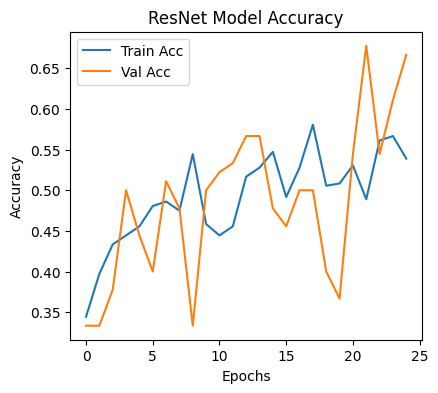

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('ResNet Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

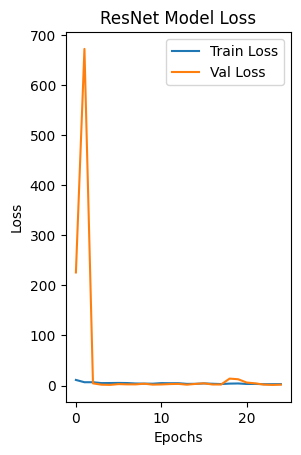

In [26]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('ResNet Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Alternative ResNet Configuration

Using a simpler ResNet-inspired architecture with custom configuration.

In [ ]:
def build_custom_resnet():
    """Build a custom ResNet-inspired model with skip connections."""
    inputs = layers.Input(shape=(128, 128, 1))
    
    # Convert grayscale to 3 channels
    x = layers.Conv2D(3, (1, 1), padding='same', name='rgb_conv')(inputs)
    
    # Initial Conv Block
    x = layers.Conv2D(64, (7, 7), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)
    
    # ResNet Block 1
    shortcut1 = x
    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut1])
    x = layers.Activation('relu')(x)
    
    # ResNet Block 2
    shortcut2 = layers.Conv2D(128, (1, 1), strides=2, use_bias=False)(x)
    shortcut2 = layers.BatchNormalization()(shortcut2)
    x = layers.Conv2D(128, (3, 3), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut2])
    x = layers.Activation('relu')(x)
    
    # ResNet Block 3
    shortcut3 = layers.Conv2D(256, (1, 1), strides=2, use_bias=False)(x)
    shortcut3 = layers.BatchNormalization()(shortcut3)
    x = layers.Conv2D(256, (3, 3), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut3])
    x = layers.Activation('relu')(x)
    
    # ResNet Block 4
    shortcut4 = layers.Conv2D(512, (1, 1), strides=2, use_bias=False)(x)
    shortcut4 = layers.BatchNormalization()(shortcut4)
    x = layers.Conv2D(512, (3, 3), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(512, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut4])
    x = layers.Activation('relu')(x)
    
    # Global Average Pooling and Dense layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(1500, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    
    model = models.Model(inputs, outputs, name='Custom_ResNet')
    return model

In [ ]:
resnet = build_custom_resnet()
resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
resnet.summary()

In [ ]:
training_history = resnet.fit(x=train_gen, validation_data=val_gen, epochs=25)

In [ ]:
val_loss, val_acc = resnet.evaluate(val_gen)
print(f"\nValidation Accuracy: {val_acc*100:.2f}%")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(training_history.history['accuracy'], label='Train Acc')
plt.plot(training_history.history['val_accuracy'], label='Val Acc')
plt.title('Custom ResNet Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [ ]:
plt.subplot(1,2,2)
plt.plot(training_history.history['loss'], label='Train Loss')
plt.plot(training_history.history['val_loss'], label='Val Loss')
plt.title('Custom ResNet Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()